# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


### 2. Импортируем датасет

In [5]:
df = pd.read_csv(r'C:\Users\pasha\OneDrive\Рабочий стол\7 Random forest\train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [6]:
print(df.shape)
display(df.head())
print(df.info())
print(df.isnull().sum())
print(df['Survived'].value_counts())


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Survived
0   

### 4. Сформируем обучающую и тестовую выборки:


In [7]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(712, 11) (179, 11)


### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [8]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X_train = X_train[features].copy()
X_test = X_test[features].copy()

X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
X_test['Age'] = X_test['Age'].fillna(X_train['Age'].median())

X_train['Embarked'] = X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])
X_test['Embarked'] = X_test['Embarked'].fillna(X_train['Embarked'].mode()[0])

X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train.head()


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
692,3,28.5,0,0,56.4958,True,False,True
481,2,28.5,0,0,0.0000,True,False,True
527,1,28.5,0,0,221.7792,True,False,True
855,3,18.0,0,1,9.3500,False,False,True
801,2,31.0,1,1,26.2500,False,False,True


### 6. Построение базовой модели:

In [9]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)


### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [10]:
def evaluate_model(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print(classification_report(y_test, y_pred))


#### 7.2. Оцените точность модели:

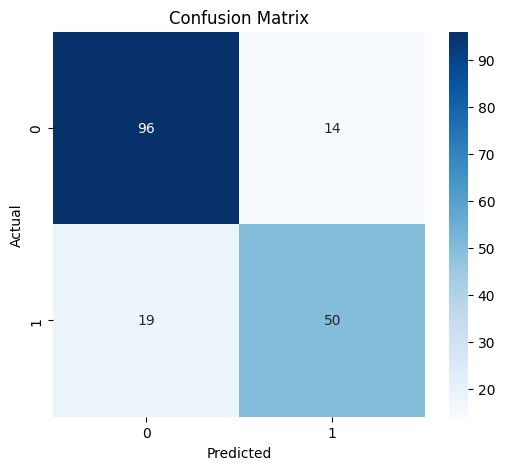

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

Accuracy: 0.8156424581005587


In [11]:
evaluate_model(y_test, y_pred)
print('Accuracy:', accuracy_score(y_test, y_pred))


### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [12]:
params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 15],
    'max_leaf_nodes': [None, 10, 20, 30]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=params,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print('Лучшие параметры:', random_search.best_params_)
print('Лучшая точность:', random_search.best_score_)


Лучшие параметры: {'n_estimators': 100, 'max_leaf_nodes': 20, 'max_depth': 15}
Лучшая точность: 0.8286529801794136


#### GridSearchCV

In [13]:
params_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'max_leaf_nodes': [None, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Лучшие параметры:', grid_search.best_params_)
print('Лучшая точность:', grid_search.best_score_)


Лучшие параметры: {'max_depth': 5, 'max_leaf_nodes': 20, 'n_estimators': 50}
Лучшая точность: 0.8314659197012139


### 9. Комплексная оценка точности лучшей модели:

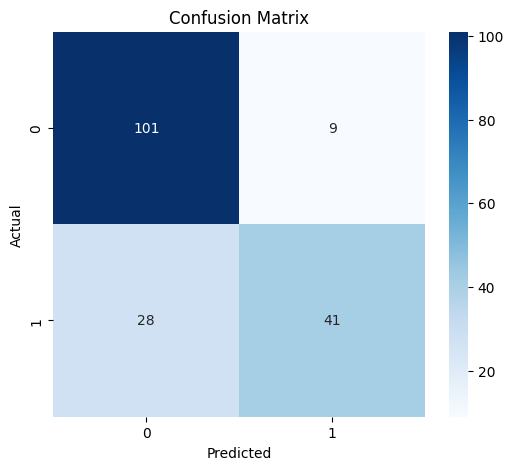

              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179

Accuracy: 0.7932960893854749


Sex_male      0.434326
Fare          0.164779
Pclass        0.157699
Age           0.126587
SibSp         0.041347
Parch         0.031981
Embarked_S    0.031635
Embarked_Q    0.011647
dtype: float64

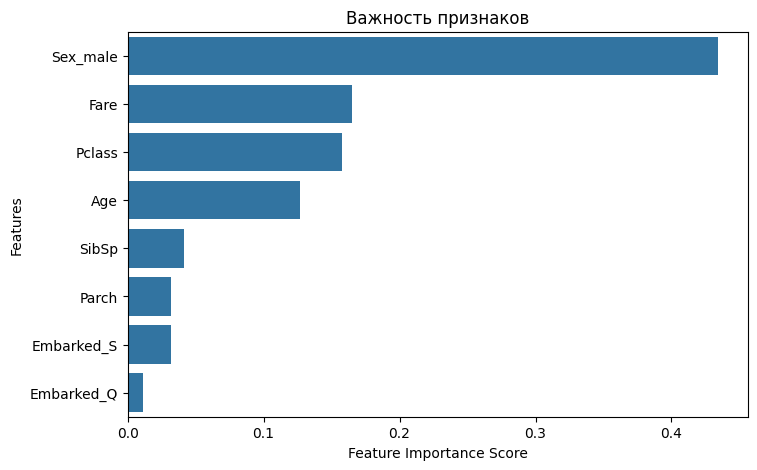

In [14]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

evaluate_model(y_test, y_pred_best)
print('Accuracy:', accuracy_score(y_test, y_pred_best))

feature_scores = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(feature_scores)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Важность признаков')
plt.show()


## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [15]:
models = {
    'Random Forest': best_model,
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, 'Accuracy:', accuracy_score(y_test, pred))


Random Forest Accuracy: 0.7932960893854749
Decision Tree Accuracy: 0.8268156424581006
KNN Accuracy: 0.6815642458100558


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [16]:
def predict_passenger(model):
    try:
        pclass = int(input('Класс билета (1, 2 или 3): '))
        sex = input('Пол (male/female): ').lower()
        age = float(input('Возраст (0-100): '))
        sibsp = int(input('Количество братьев/сестер/супругов: '))
        parch = int(input('Количество родителей/детей: '))
        fare = float(input('Стоимость билета: '))
        embarked = input('Порт посадки (C/Q/S): ').upper()

        if pclass not in [1, 2, 3]:
            raise ValueError('Класс должен быть 1, 2 или 3')
        if sex not in ['male', 'female']:
            raise ValueError('Пол должен быть male или female')
        if age < 0 or age > 100:
            raise ValueError('Возраст должен быть от 0 до 100')
        if embarked not in ['C', 'Q', 'S']:
            raise ValueError('Порт должен быть C, Q или S')

        passenger = pd.DataFrame([{
            'Pclass': pclass,
            'Sex': sex,
            'Age': age,
            'SibSp': sibsp,
            'Parch': parch,
            'Fare': fare,
            'Embarked': embarked
        }])

        passenger = pd.get_dummies(
            passenger,
            columns=['Sex', 'Embarked'],
            drop_first=True
        )

        passenger = passenger.reindex(columns=X_train.columns, fill_value=0)

        result = model.predict(passenger)[0]

        if result == 1:
            print('Модель считает, что пассажир выжил')
        else:
            print('Модель считает, что пассажир не выжил')

    except ValueError as e:
        print('Ошибка:', e)


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [20]:

reg_data = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
reg_data['Age'] = reg_data['Age'].fillna(reg_data['Age'].median())

X_reg = reg_data.drop('Fare', axis=1)
y_reg = reg_data['Fare']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 15],
    'max_leaf_nodes': [None, 10, 20, 30]
}

rf_reg = RandomForestRegressor(random_state=42)

random_search_reg = RandomizedSearchCV(
    rf_reg,
    param_distributions=params,
    n_iter=5,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

random_search_reg.fit(X_train_reg, y_train_reg)

print('Лучшие параметры RandomizedSearchCV:', random_search_reg.best_params_)

params_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'max_leaf_nodes': [None, 10, 20]
}

grid_search_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search_reg.fit(X_train_reg, y_train_reg)

print('Лучшие параметры GridSearchCV:', grid_search_reg.best_params_)

best_reg = grid_search_reg.best_estimator_
pred_reg = best_reg.predict(X_test_reg)

print('MSE:', mean_squared_error(y_test_reg, pred_reg))
print('R2:', r2_score(y_test_reg, pred_reg))


Лучшие параметры RandomizedSearchCV: {'n_estimators': 50, 'max_leaf_nodes': 10, 'max_depth': 10}
Лучшие параметры GridSearchCV: {'max_depth': None, 'max_leaf_nodes': 10, 'n_estimators': 50}
MSE: 1091.376610844544
R2: 0.2947164787722727


## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [18]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [22]:
import pandas as pd

data = pd.read_csv(r'C:\Users\pasha\OneDrive\Рабочий стол\7 Random forest\dog_food.csv')

In [ ]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


C    0.903895
D    0.035035
A    0.032304
B    0.028766
dtype: float64

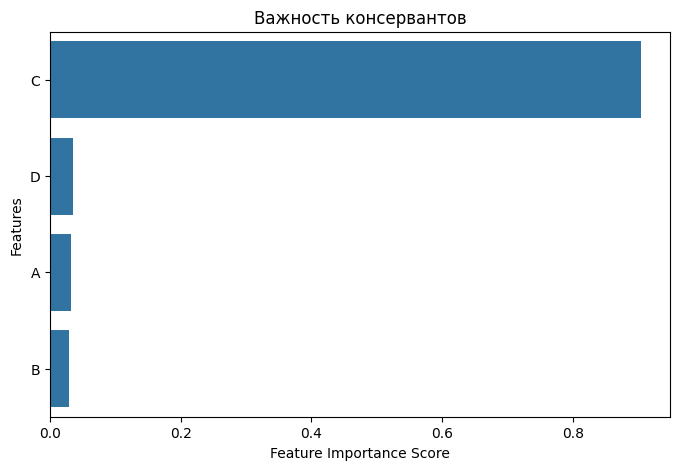

In [23]:
X = data[['A', 'B', 'C', 'D']]
y = data['Spoiled']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importance)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance, y=importance.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Важность консервантов')
plt.show()